In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


In [6]:
DATASET_PATH = r"C:\Users\Akshada\OneDrive\Documents\DL Lab\train"
print("Dataset Path:", DATASET_PATH)
if os.path.exists(DATASET_PATH):
    print("Dataset found successfully!")
else:
    print("Dataset path not found.")

Dataset Path: C:\Users\Akshada\OneDrive\Documents\DL Lab\train
Dataset found successfully!


In [1]:
#find rhe classes
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes found:\n")
for i, class_name in enumerate(classes):
    print(i, ":", class_name)

print("\nTotal Classes:", len(classes))

print("Images per class:\n")
class_counts = {}
for class_name in classes:
    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )
    count = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ])
    class_counts[class_name] = count
    print(
        f"{class_name}: {count}"
    )

NameError: name 'os' is not defined

In [10]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 24
VALIDATION_SPLIT = 0.15
SEED = 42
EPOCHS = 18
NUM_CLASSES = 6

In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)
class_names = train_ds.class_names
print("Class mapping:\n")
for index, name in enumerate(class_names):
    print(
        index,
        "→",
        name
    )

Found 4586 files belonging to 6 classes.
Using 3899 files for training.
Found 4586 files belonging to 6 classes.
Using 687 files for validation.
Class mapping:

0 → Tomato___Bacterial_spot
1 → Tomato___Early_blight
2 → Tomato___Late_blight
3 → Tomato___Leaf_Mold
4 → Tomato___Septoria_leaf_spot
5 → Tomato___healthy


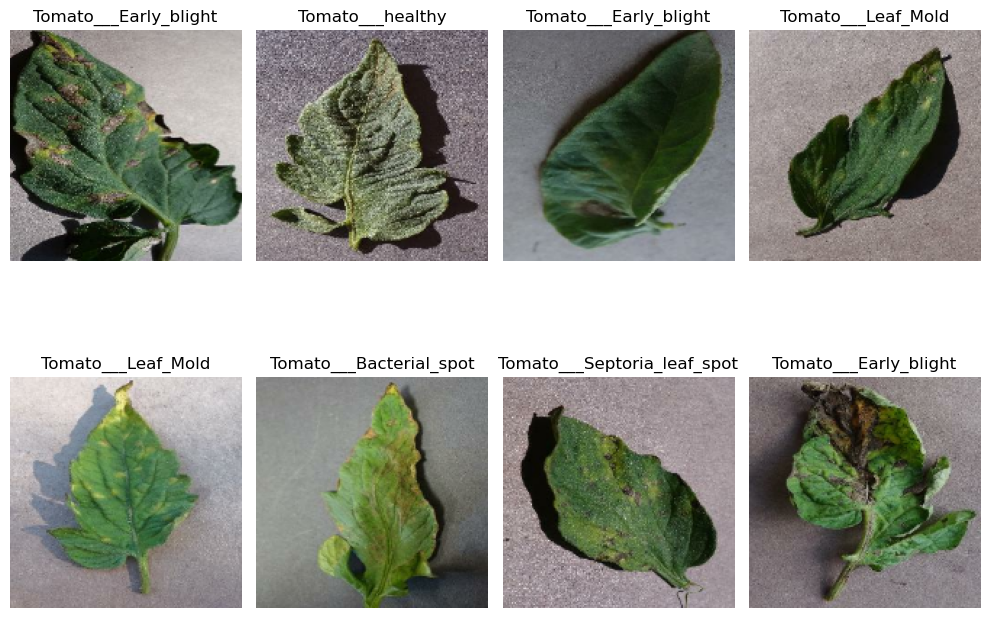

In [17]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(
            images[i].numpy().astype("uint8"))
        plt.title(
            class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        "horizontal"
    ),
    layers.RandomRotation(
        0.15
    ),
    layers.RandomZoom(
        height_factor=(-0.1, 0.15),
        width_factor=(-0.1, 0.15)
    ),
    layers.RandomContrast(
        0.1
    )
])

In [19]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(
    AUTOTUNE
)
val_ds = val_ds.prefetch(
    AUTOTUNE
)

In [20]:
model = models.Sequential([
    layers.Input(
        shape=(160, 160, 3)
    ),
    layers.Rescaling(
        1.0 / 255
    ),
    augmentation,
    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),
layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),
layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    layers.MaxPooling2D(
        (2, 2)
    ),
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation="relu"
    ),
    layers.Dropout(
        0.4
    ),
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [22]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping
    ]
)

Epoch 1/18


C:\Users\Akshada\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


163/163 ━━━━━━━━━━━━━━━━━━━━ 63s 354ms/step - accuracy: 0.2531 - loss: 1.6922 - val_accuracy: 0.2329 - val_loss: 1.7828
Epoch 2/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 64s 394ms/step - accuracy: 0.4583 - loss: 1.3578 - val_accuracy: 0.4338 - val_loss: 1.3426
Epoch 3/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.5060 - loss: 1.1933 - val_accuracy: 0.4425 - val_loss: 1.2183
Epoch 4/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 359ms/step - accuracy: 0.5966 - loss: 1.0265 - val_accuracy: 0.4702 - val_loss: 1.2509
Epoch 5/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 57s 349ms/step - accuracy: 0.6566 - loss: 0.9180 - val_accuracy: 0.5517 - val_loss: 1.1756
Epoch 6/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 385ms/step - accuracy: 0.6994 - loss: 0.7999 - val_accuracy: 0.6783 - val_loss: 0.8098
Epoch 7/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 62s 374ms/step - accuracy: 0.7140 - loss: 0.7300 - val_accuracy: 0.6012 - val_loss: 0.9886
Epoch 8/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 59s 363ms/step - accuracy: 0.7715 - loss: 0.6138 - val

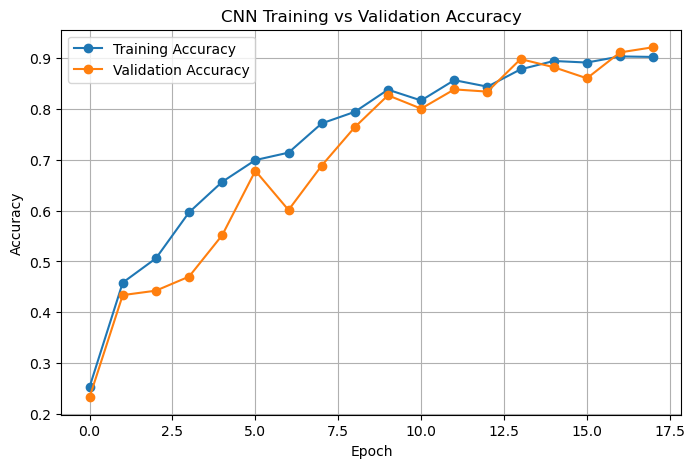

In [25]:
# graphs
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "CNN Training vs Validation Accuracy"
)
plt.legend()
plt.grid()
plt.show()

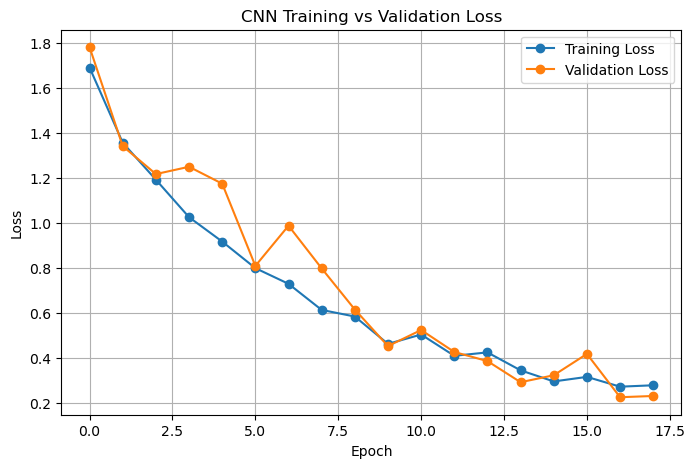

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [27]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)
print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)
print(
    f"Validation Loss: "
    f"{val_loss:.4f}"
)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9112 - loss: 0.2254
Validation Accuracy: 91.12%
Validation Loss: 0.2254
